# SHAP-IMV — results across the three examples

Everything the three `src/empirical/shap_imv/*.ipynb` notebooks produced, gathered in one place: the top-5 feature-selection comparison as one LaTeX table, the SHAP-IMV ranking of the variables in each example as a second one, and a 3×3 figure showing that ranking.

Nothing is recomputed here. The tables are read back from `output/examples/shap/` and the artefact cache, so this notebook is cheap to re-run and cannot disagree with the examples it summarises. Run the three example notebooks first if a file is missing.

Both `.tex` files are written to `output/tables/` as complete `table` environments, ready for `\input`. They are regenerated on every run, so any edit belongs in the constants below rather than in the file — the citation keys in particular.

The figure style — panel size, palette, weights, sizes, edge colour — comes from `src/empirical/plotter/shared_style.py`, so any other notebook can import it and produce panels that sit beside these without retouching.

Optional setup: set `INSTALL_REQUIREMENTS = True` in the first code cell to install this project's requirements into the current kernel. It defaults to `False` so ordinary plotting runs do not install packages or require network access.

In [1]:
import os, sys
from pathlib import Path

PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "requirements.txt").is_file() and (path / "src").is_dir()),
    Path.cwd(),
)

INSTALL_REQUIREMENTS = False
if INSTALL_REQUIREMENTS:
    %pip install -r "{PROJECT_ROOT / 'requirements.txt'}"

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def relative_path(path, *, start=None):
    """Display-only path, anchored so no absolute home path reaches an output."""
    anchor = Path(start) if start is not None else PROJECT_ROOT
    try:
        relative = os.path.relpath(Path(path).expanduser().resolve(),
                                   start=Path(anchor).expanduser().resolve())
    except ValueError:  # different Windows drives cannot be relativized
        relative = Path(path).name
    return Path(relative).as_posix()

# The style package lives under src/ so every notebook, wherever it sits,
# imports the same one.
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
from empirical.plotter import shared_style
from empirical.plotter.figure_utils import save_publication_figure as save_figure

CACHE = Path(os.environ.get("IMV_CACHE_HOME", Path.home() / ".cache" / "imv"))
ARTIFACTS = Path(os.environ.get("IMV_ARTIFACT_CACHE", CACHE / "notebook_artifacts"))
OUTPUT = PROJECT_ROOT / "output" / "examples" / "shap"
OUTPUT.mkdir(parents=True, exist_ok=True)
TABLES = PROJECT_ROOT / "output" / "tables"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES = Path(os.environ.get("IMV_FIGURE_DIR", PROJECT_ROOT / "output" / "figures"))
FIGURES.mkdir(parents=True, exist_ok=True)

# Datasets in the column order of the table; each notebook is named for its
# example and its artefacts for the dataset slug inside it.
EXAMPLES = {"shap_imv_titanic": ("titanic", "Titanic"),
            "shap_imv_breast_cancer": ("breast_cancer", "Breast Cancer"),
            "shap_imv_adult_income": ("adult_income", "Adult Income")}
MODEL_NAMES = ("logistic_regression", "xgboost", "lightgbm")
MODEL_LABELS = {"logistic_regression": "LR", "xgboost": "XGB", "lightgbm": "LGBM"}
MODEL_TITLES = {"logistic_regression": "Logistic Regression",
                "xgboost": "XGBoost", "lightgbm": "LightGBM"}
METHOD_NAMES = ("shap_imv", "shap", "lime", "anchors")
METHOD_LABELS = {"shap_imv": "SHAP-IMV", "shap": "SHAP", "lime": "LIME",
                 "anchors": "Anchors"}
# The manuscript cites the three baselines in the text rather than in the table,
# so no key is emitted by default. Fill this in — {"shap": r"\cite{SHAP}"} and so
# on — to put them back; the keys have to exist in the bibliography, so edit them
# here rather than in the generated .tex, which every run overwrites.
METHOD_CITATIONS = {}
METRICS = {"accuracy_mean": "Accuracy", "precision_mean": "Precision"}
TOP_K = 5

# Short display names for the ranking table; anything missing falls through to
# the raw column name, escaped.
FEATURE_LABELS = {"AgeClass": r"Age$\times$Class", "Alone": "Alone",
                  "sex_female": "Sex (female)", "race_white": "Race (white)",
                  "age": "Age", "education-num": "Education",
                  "hours-per-week": "Hours/week", "married": "Married",
                  "capital-gain": "Capital gain", "capital-loss": "Capital loss",
                  "radius1": "Radius", "texture1": "Texture",
                  "smoothness1": "Smoothness", "compactness1": "Compactness",
                  "symmetry1": "Symmetry", "fractal_dimension1": "Fractal dim.",
                  "concavity1": "Concavity", "concave_points1": "Concave points"}

shared_style.apply()
print(f"fonts: {', '.join(shared_style.FONT_FAMILY)}")
print(f"style: {shared_style.PALETTE} palette, "
      f"{shared_style.PANEL_WIDTH}×{shared_style.PANEL_HEIGHT}in panels, "
      f"base font {shared_style.BASE_FONT_SIZE}pt")
print(f"reading from {relative_path(OUTPUT)}/ and {relative_path(ARTIFACTS)}/")

fonts: Helvetica, DejaVu Sans
style: imv palette, 5.4×4.6in panels, base font 11pt
reading from output/examples/shap/ and ../../.cache/imv/notebook_artifacts/


## 1. Load what the examples wrote

Each file is looked up under `output/examples/shap/` first and in the artefact cache second, so a checkout that ships only `output/` still renders everything: the per-feature SHAP-IMV summary lives in the cache, and where it is absent the ranking is recovered from the published top-5 table instead.

The per-example tables are then concatenated into two cross-example CSVs, which is the one thing this notebook adds rather than repeats.

In [2]:
def write_csv_atomic(table, path, *, index=False):
    """Replace a CSV only after its complete contents reach the same directory."""
    temporary = path.with_name(f".{path.name}.{os.getpid()}.tmp")
    try:
        table.to_csv(temporary, index=index)
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)

def read_result(example, filename, **read_kwargs):
    """Read one artefact, preferring the published copy under output/."""
    candidates = [OUTPUT / filename, ARTIFACTS / example / "results" / filename]
    for path in candidates:
        if path.is_file():
            return pd.read_csv(path, **read_kwargs)
    raise FileNotFoundError(
        f"{filename} is missing; run src/empirical/shap_imv/{example}.ipynb "
        f"first (looked in {', '.join(relative_path(path) for path in candidates)})")

def ranking_from_top_k(top_k):
    """The SHAP-IMV ranking recovered from the published top-k table.

    The table keeps the selected features in order with their values and the
    dropped ones without, so the ranking survives in full and only the values
    below the cut are lost.
    """
    rows = []
    for _, row in top_k[top_k["method"] == "shap_imv"].iterrows():
        selected = row["selected_features"].split(";")
        values = [float(value) for value in row["importance"].split(";")]
        dropped = [name for name in str(row["dropped_features"]).split(";") if name]
        rows += [{"model": row["model"], "feature": name, "mean": value,
                  "std": np.nan} for name, value in zip(selected, values)]
        rows += [{"model": row["model"], "feature": name, "mean": np.nan,
                  "std": np.nan} for name in dropped]
    return pd.DataFrame(rows)

def load_ranking(example, dataset, top_k):
    """Mean SHAP-IMV per feature and estimator, ranked, for one example."""
    try:
        summary = read_result(example, f"{dataset}_shap_imv_summary.csv")
    except FileNotFoundError:
        summary = ranking_from_top_k(top_k)
        print(f"  {example}: no per-feature summary in the cache; ranking read "
              f"off the top-{TOP_K} table, so the dropped features carry no value")
    summary = summary[summary["model"].isin(MODEL_NAMES)].copy()
    # Rank within an estimator, strongest first. A feature with no value — the
    # fallback above — sorts last, which is where the top-k table left it.
    summary["rank"] = (summary.groupby("model")["mean"]
                       .rank(ascending=False, method="first", na_option="bottom")
                       .astype(int))
    return summary.sort_values(["model", "rank"]).reset_index(drop=True)

def load_example(example, dataset, title):
    """One example's top-k selection table and its SHAP-IMV feature ranking."""
    top_k = read_result(example, f"{example}_top_{TOP_K}_features.csv")
    missing = sorted({(model, method) for model in MODEL_NAMES
                      for method in METHOD_NAMES}
                     - set(map(tuple, top_k[["model", "method"]].to_numpy())))
    if missing:
        raise ValueError(f"{example}: no top-{TOP_K} results for {missing}")
    return {"example": example, "dataset": dataset, "title": title,
            "top_k": top_k, "ranking": load_ranking(example, dataset, top_k),
            "n_seeds": int(top_k["n_seeds"].iloc[0]),
            "n_splits": int(top_k["n_splits"].iloc[0])}

results = {example: load_example(example, dataset, title)
           for example, (dataset, title) in EXAMPLES.items()}
# Every number in both tables is a mean over the same protocol; a mismatch would
# make the captions below wrong rather than merely imprecise.
protocol = {(result["n_seeds"], result["n_splits"]) for result in results.values()}
if len(protocol) != 1:
    raise ValueError(f"the examples disagree on seeds × folds: {sorted(protocol)}")
N_SEEDS, N_SPLITS = protocol.pop()
for result in results.values():
    features = result["ranking"].query("model == 'logistic_regression'")["feature"]
    print(f"{result['title']:<15} {len(features)} features, {N_SEEDS} seeds × "
          f"{N_SPLITS} folds: {', '.join(features)}")

combined_top_k = pd.concat([result["top_k"] for result in results.values()],
                           ignore_index=True)
combined_ranking = pd.concat(
    [result["ranking"].assign(example=result["example"], dataset=result["title"])
     for result in results.values()],
    ignore_index=True)[["example", "dataset", "model", "rank", "feature", "mean",
                        "std"]].rename(columns={"mean": "shap_imv_mean",
                                                "std": "shap_imv_std"})

for table, name in ((combined_top_k, "top_k_metrics"),
                    (combined_ranking, "feature_ranking")):
    write_csv_atomic(table, OUTPUT / f"shap_imv_results__{name}.csv")
print(f"wrote two cross-example tables to {relative_path(OUTPUT)}/")
combined_ranking.head(12)

Titanic         8 features, 10 seeds × 10 folds: Sex, Title, Class, AgeClass, Fare, Embarked, Alone, Age
Breast Cancer   8 features, 10 seeds × 10 folds: concave_points1, radius1, concavity1, compactness1, texture1, smoothness1, symmetry1, fractal_dimension1
Adult Income    8 features, 10 seeds × 10 folds: married, education-num, capital-gain, age, hours-per-week, sex_female, capital-loss, race_white
wrote two cross-example tables to output/examples/shap/


,example,dataset,model,rank,feature,shap_imv_mean,shap_imv_std
0,shap_imv_titanic,Titanic,lightgbm,1,Title,0.1127,0.001829
1,shap_imv_titanic,Titanic,lightgbm,2,Sex,0.1043,0.002058
2,shap_imv_titanic,Titanic,lightgbm,3,Fare,0.0531,0.005087
3,shap_imv_titanic,Titanic,lightgbm,4,Class,0.0458,0.001751
4,shap_imv_titanic,Titanic,lightgbm,5,AgeClass,0.0248,0.004185
5,shap_imv_titanic,Titanic,lightgbm,6,Embarked,0.0121,0.001729
6,shap_imv_titanic,Titanic,lightgbm,7,Alone,0.0087,0.000949
7,shap_imv_titanic,Titanic,lightgbm,8,Age,0.0008,0.003155
8,shap_imv_titanic,Titanic,logistic_regression,1,Sex,0.1466,0.002319
9,shap_imv_titanic,Titanic,logistic_regression,2,Title,0.0649,0.002558


## 2. Table 1 — top-5 feature selection

Each attribution method ranks the features; the top five of each ranking refit the same estimator, and accuracy and precision are averaged over ten folds for each of ten seeds. Columns are the three datasets and their unweighted average, rows the three estimators × four methods. The environment is the manuscript's: a full-width `table*` inside a `\resizebox`, with the second and fourth method of each block shaded as row striping.

**Bold** is the best value and <u>underline</u> the runner-up, within one estimator block and one column. Six features choosing five leaves the four methods room to agree, and they often do: where all four pick the same subset the four numbers are identical, and that column is left unmarked rather than declaring a winner among equals.

In [3]:
# Row striping, applied to every cell of every second row of a block, as in the
# manuscript. It needs \usepackage[table]{xcolor}; set it to None to drop that
# dependency and leave the rows unshaded.
ROW_SHADE_COLOR = "gray!15"

def escape_latex(text):
    """Escape the characters that actually occur in these names."""
    replacements = {"\\": r"\textbackslash{}", "&": r"\&", "%": r"\%", "$": r"\$",
                    "#": r"\#", "_": r"\_", "{": r"\{", "}": r"\}",
                    "~": r"\textasciitilde{}", "^": r"\textasciicircum{}"}
    return "".join(replacements.get(character, character) for character in str(text))

def method_label(method):
    """The method as the table prints it, with its citation where it has one."""
    citation = METHOD_CITATIONS.get(method, "")
    return METHOD_LABELS[method] + (f"~{citation}" if citation else "")

def specification_note():
    """The sentence both captions carry about the fixed feature specification.

    Exact Shapley attribution evaluates one model per subset, so each example
    fixes a small specification rather than taking the dataset whole. Saying so
    in the caption keeps a reader from reading the ranking as a complete one.
    """
    widths = {result["title"]: int(result["ranking"]["rank"].max())
              for result in results.values()}
    distinct = sorted(set(widths.values()))
    specification = (f"a fixed {distinct[0]}-variable specification"
                     if len(distinct) == 1 else
                     "a fixed specification ("
                     + ", ".join(f"{width} for {title}"
                                 for title, width in widths.items()) + ")")
    return (f"The variables of each dataset are {specification} carried over "
            f"from the example notebooks, not the dataset's full variable list: "
            f"exact Shapley attribution costs one model evaluation per subset "
            f"of them.")

def metrics_matrix():
    """Percentages per (estimator, method) × (dataset, metric), plus the average.

    The average is over datasets, not over the pooled folds: each dataset counts
    once whatever its size, which is how the column is read.
    """
    titles = [title for _, title in EXAMPLES.values()]
    wide = (combined_top_k
            .assign(dataset=combined_top_k["example"].map(lambda name: EXAMPLES[name][1]))
            .pivot_table(index=["model", "method"], columns="dataset",
                         values=list(METRICS)))
    matrix = pd.DataFrame({(title, metric): 100 * wide[(metric, title)]
                           for title in titles for metric in METRICS})
    for metric in METRICS:
        matrix[("Average", metric)] = np.mean(
            [matrix[(title, metric)] for title in titles], axis=0)
    matrix.columns = pd.MultiIndex.from_tuples(
        [(title, METRICS[metric]) for title, metric in matrix.columns],
        names=["dataset", "metric"])
    return matrix.reindex(pd.MultiIndex.from_product([MODEL_NAMES, METHOD_NAMES],
                                                     names=["model", "method"]))

def marked_cells(column):
    """`{method: latex}` for one column of one estimator block.

    Marks are applied to the printed value, so two methods that agree to two
    decimals are marked alike. A column whose four methods all agree separates
    nothing and is left plain.
    """
    values = column.round(2)
    distinct = sorted(set(values), reverse=True)
    best = distinct[0] if len(distinct) > 1 else None
    runner_up = distinct[1] if len(distinct) > 1 else None
    marks = {best: r"\textbf", runner_up: r"\underline"}
    return {method: (rf"{marks[value]}{{{value:.2f}}}" if value in marks
                     else f"{value:.2f}")
            for method, value in values.items()}

def shaded(cells, position):
    """Every second row of a block carries the stripe on each of its cells."""
    if position % 2 == 0 or not ROW_SHADE_COLOR:
        return cells
    return [rf"\cellcolor{{{ROW_SHADE_COLOR}}}{cell}" for cell in cells]

def metrics_latex(matrix):
    """The top-k selection table as the manuscript's full-width table environment."""
    datasets = list(dict.fromkeys(title for title, _ in matrix.columns))
    width = len(METRICS)
    lines = [
        r"\begin{table*}[h]",
        r"\centering",
        r"\tabcolsep=3pt",
        rf"\caption{{Results of the performance of SHAP-IMV, SHAP, LIME, and "
        rf"Anchors under three machine learning methods. LR represents Logistic "
        rf"Regression, XGB represents XGBoost, and LGBM represents LightGBM. For "
        rf"each dataset, the top {TOP_K} most important features as selected by "
        rf"the different baseline algorithms under each machine learning method "
        rf"are used to train the model. The accuracy and precision are averaged "
        rf"over {N_SPLITS} folds for each of {N_SEEDS} seeds, and the average "
        rf"weights the {len(EXAMPLES)} datasets equally. The best and second best "
        rf"are noted in bold font and underlined; a column on which all four "
        rf"methods agree is left unmarked. {specification_note()}}}",
        r"\resizebox{\textwidth}{!}{",
        r"    \begin{tabular}{" + "c" * (2 + len(matrix.columns)) + "}",
        r"        \toprule",
        r"         \multicolumn{2}{c}{\multirow{2}{*}{Methods}} & "
        + " & ".join(rf"\multicolumn{{{width}}}{{c}}{{{title}}}" for title in datasets)
        + r"\\",
        r"         &  & " + " & ".join(metric for _, metric in matrix.columns)
        + r" \\",
        r"        \midrule",
    ]
    for position, model in enumerate(MODEL_NAMES):
        if position:
            lines.append(r"        \midrule")
        block = matrix.loc[model]
        marks = {column: marked_cells(block[column]) for column in block.columns}
        lines.append(rf"        \multirow{{{len(METHOD_NAMES)}}}{{*}}{{{MODEL_LABELS[model]}}}")
        for offset, method in enumerate(METHOD_NAMES):
            cells = shaded([method_label(method)]
                           + [marks[column][method] for column in block.columns],
                           offset)
            lines.append("        & " + " & ".join(cells) + r"\\")
    lines += [
        r"        \bottomrule",
        rf"        \label{{{METRICS_LABEL}}}",
        r"    \end{tabular}}",
        r"    \vspace{-0.4cm}",
        r"\end{table*}",
    ]
    return "\n".join(lines)

def write_latex(body, path, *, packages):
    """Write a generated table, stamped with its source and its requirements."""
    header = (f"% Generated by {SOURCE}; do not edit by hand.\n"
              f"% Requires: {', '.join(packages)}.\n")
    temporary = path.with_name(f".{path.name}.{os.getpid()}.tmp")
    try:
        temporary.write_text(header + body + "\n")
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)
    print(relative_path(path))
    return path

SOURCE = "src/empirical/plotter/shap_imv_results.ipynb"
# \resizebox is graphicx; the stripe is the table option of xcolor.
PACKAGES = [r"\usepackage{booktabs}", r"\usepackage{multirow}",
            r"\usepackage{graphicx}"] + ([r"\usepackage[table]{xcolor}"]
                                         if ROW_SHADE_COLOR else [])
METRICS_LABEL = "SHAPIMVTabulartable"
RANKING_LABEL = "SHAPIMVRankingtable"

metrics = metrics_matrix()
write_latex(metrics_latex(metrics), TABLES / "shap_imv_top_k.tex",
            packages=PACKAGES)
print(metrics_latex(metrics))
display(metrics.round(2)
        .rename(index=MODEL_LABELS, level="model")
        .rename(index=METHOD_LABELS, level="method"))

output/tables/shap_imv_top_k.tex
\begin{table*}[h]
\centering
\tabcolsep=3pt
\caption{Results of the performance of SHAP-IMV, SHAP, LIME, and Anchors under three machine learning methods. LR represents Logistic Regression, XGB represents XGBoost, and LGBM represents LightGBM. For each dataset, the top 5 most important features as selected by the different baseline algorithms under each machine learning method are used to train the model. The accuracy and precision are averaged over 10 folds for each of 10 seeds, and the average weights the 3 datasets equally. The best and second best are noted in bold font and underlined; a column on which all four methods agree is left unmarked. The variables of each dataset are a fixed 8-variable specification carried over from the example notebooks, not the dataset's full variable list: exact Shapley attribution costs one model evaluation per subset of them.}
\resizebox{\textwidth}{!}{
    \begin{tabular}{cccccccccc}
        \toprule
         \multi

dataset         Titanic           Breast Cancer           Adult Income  \
metric         Accuracy Precision      Accuracy Precision     Accuracy   
model method                                                             
LR    SHAP-IMV    79.50     74.36         93.92     94.27        83.78   
      SHAP        79.74     73.95         94.10     94.46        83.78   
      LIME        79.74     73.95         94.10     94.46        84.16   
      Anchors     79.50     74.36         93.92     94.27        83.78   
XGB   SHAP-IMV    80.89     78.75         93.55     92.60        85.97   
      SHAP        80.89     78.75         94.13     92.98        85.29   
      LIME        80.44     80.47         93.55     92.60        85.98   
      Anchors     80.89     78.75         94.13     92.98        85.29   
LGBM  SHAP-IMV    81.00     79.48         93.97     93.41        86.00   
      SHAP        81.00     79.48         94.39     93.87        85.30   
      LIME        80.02     79.34         94.39     93.87        86.00   
      Anchors     81.00     79.48         94.39     93.87        85.30   

dataset                   Average            
metric         Precision Accuracy Precision  
model method                                 
LR    SHAP-IMV     70.94    85.73     79.85  
      SHAP         70.94    85.87     79.78  
      LIME         71.35    86.00     79.92  
      Anchors      70.94    85.73     79.85  
XGB   SHAP-IMV     79.42    86.80     83.59  
      SHAP         75.77    86.77     82.50  
      LIME         78.96    86.66     84.01  
      Anchors      75.77    86.77     82.50  
LGBM  SHAP-IMV     79.45    86.99     84.11  
      SHAP         75.91    86.90     83.09  
      LIME         79.03    86.80     84.08  
      Anchors      75.91    86.90     83.09

## 3. Figures — the same ranking, with its spread across seeds

Two figures rather than one: Titanic on its own, as the published figure has it, and the other two examples panelled together. Every panel is lettered and names its own example and estimator — `a.` to `c.` for Titanic, `a.` to `f.` down the combined figure — with the letter set flush to the y-axis. Bars are in the ranking's order and the spread across seeds is the error bar.

Neither figure carries an overall title, so the protocol behind it — mean over ten seeds, error bars the spread across those seeds — belongs in the LaTeX caption that places it.

Every feature the example carries gets a bar; nothing is truncated here. What the bars cannot show is a variable the example never scored — the feature set is fixed in each example notebook's `FEATURES`, because exact Shapley costs one evaluation per subset of it.

Rows share a y-axis and columns do not: the three estimators of one example are meant to be read against each other, two examples are not. A negative bar would mean the feature *reduced* held-out information; none of these do.

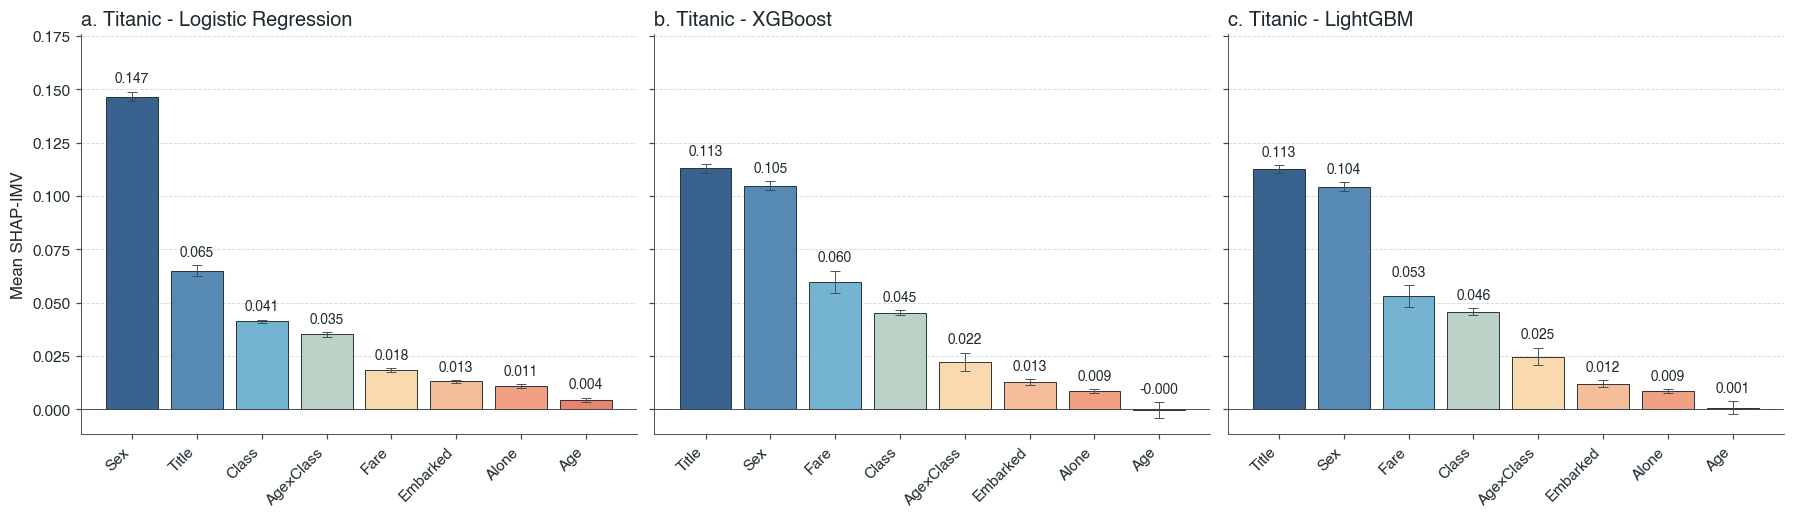

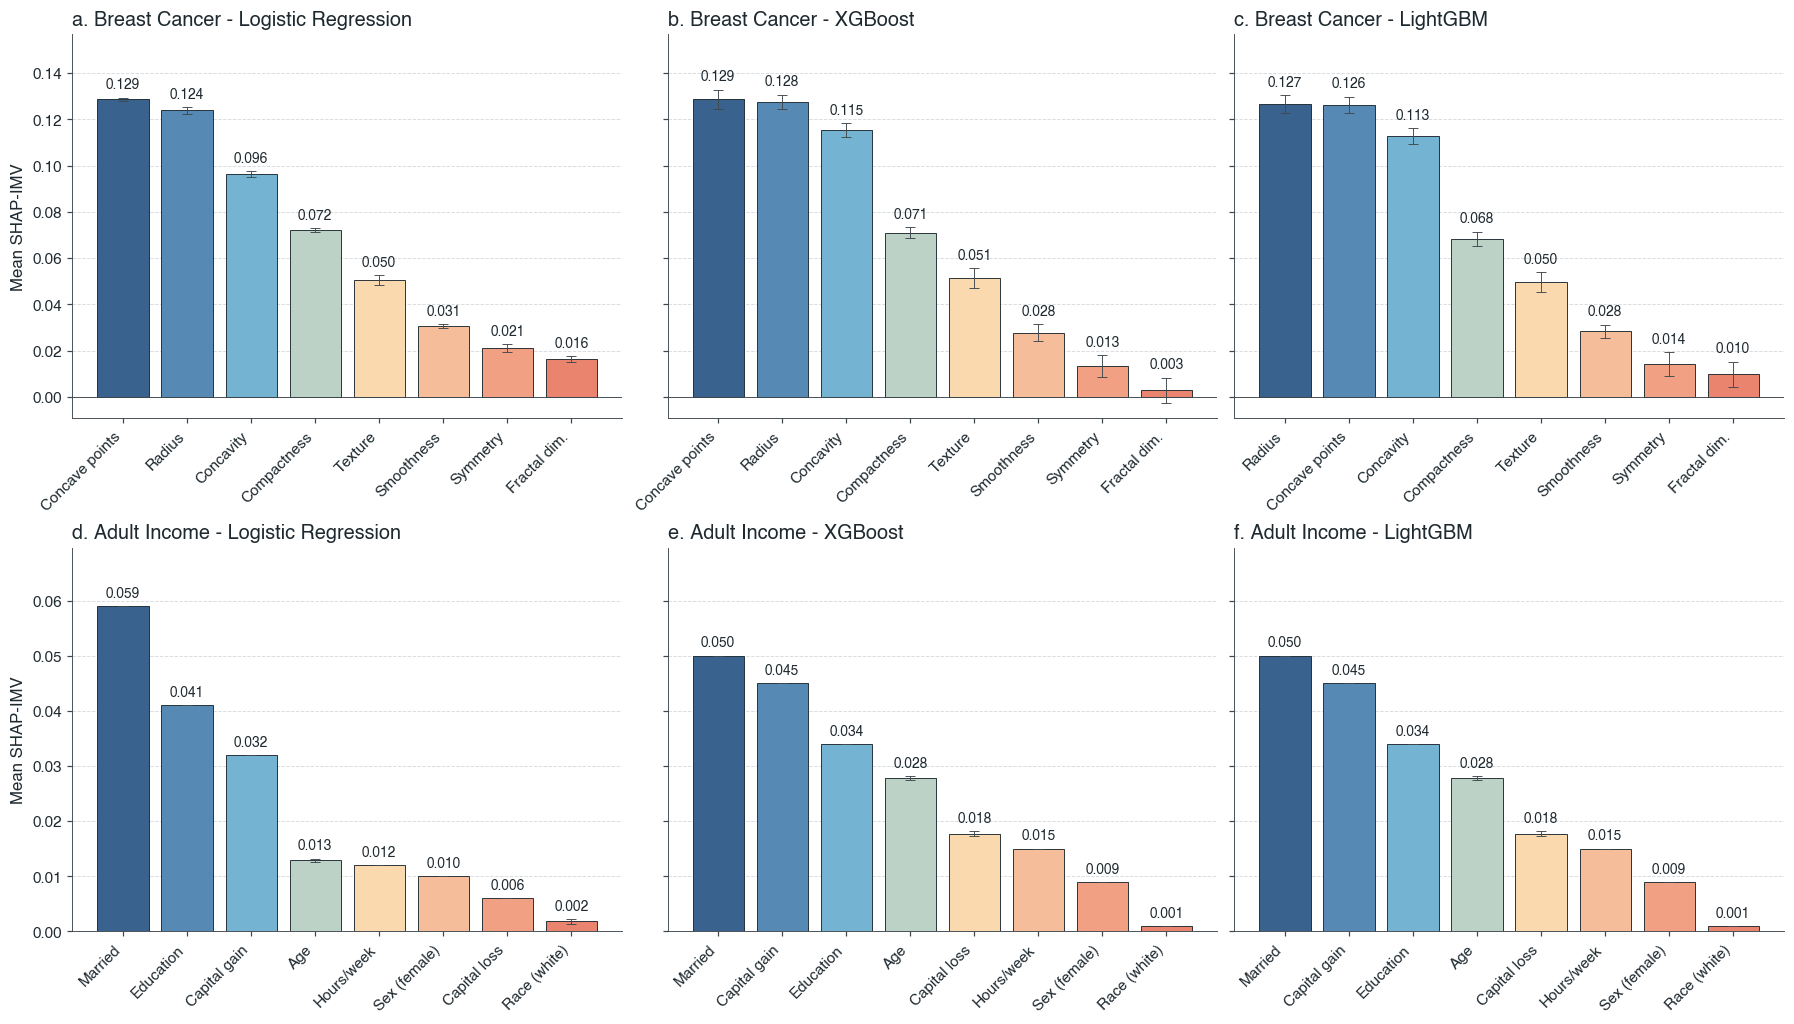

{'titanic': 'output/figures/shap_imv_results__titanic.pdf',
 'breast_cancer_adult_income': 'output/figures/shap_imv_results__breast_cancer_adult_income.pdf'}

In [4]:
# One figure per group, so Titanic stands alone and the two remaining examples
# share a panelled figure. Adding an example is a name in this tuple.
FIGURE_GROUPS = (("titanic", ("shap_imv_titanic",)),
                 ("breast_cancer_adult_income",
                  ("shap_imv_breast_cancer", "shap_imv_adult_income")))
PANEL_LETTERS = "abcdefgh"

def ranking_figure(examples):
    """Mean SHAP-IMV per feature: one row per example, one column per estimator."""
    rows = [results[example] for example in examples]
    figure, axes = plt.subplots(
        len(rows), len(MODEL_NAMES),
        figsize=shared_style.figure_size(len(rows), len(MODEL_NAMES)),
        sharey="row", squeeze=False, layout="constrained")
    for row, result in enumerate(rows):
        for column, model in enumerate(MODEL_NAMES):
            axis = axes[row, column]
            # dropna only bites on the fallback ranking, where a feature below
            # the cut has a rank but no value left to draw.
            ranked = (result["ranking"].query("model == @model")
                      .sort_values("rank").dropna(subset=["mean"]))
            labels = [FEATURE_LABELS.get(name, name).replace(r"$\times$", "×")
                      for name in ranked["feature"]]
            spread = ranked["std"].fillna(0)
            axis.bar(labels, ranked["mean"], yerr=spread,
                     **shared_style.bar_style(len(ranked)))
            axis.axhline(0, color=shared_style.AXIS_COLOR,
                         linewidth=shared_style.EDGE_WIDTH)
            # The mean above its own bar, clear of the error bar's cap. Three
            # decimals is what the ranking table prints, so the two agree.
            for position, (value, deviation) in enumerate(zip(ranked["mean"], spread)):
                axis.annotate(f"{value:.3f}", (position, value + deviation),
                              textcoords="offset points", xytext=(0, 4),
                              ha="center", va="bottom",
                              fontsize=shared_style.ANNOTATION_FONT_SIZE,
                              color=shared_style.TEXT_COLOR)
            axis.set_xticks(range(len(labels)))
            axis.set_xticklabels(labels, rotation=45, ha="right")
            # Letters run across the row and then down, and each panel names
            # what it shows, so the figure needs no title of its own. loc="left"
            # sets the label flush to the y-axis rather than over the panel.
            letter = PANEL_LETTERS[row * len(MODEL_NAMES) + column]
            axis.set_title(f"{letter}. {result['title']} - {MODEL_TITLES[model]}",
                           loc="left", **shared_style.TITLE_KWARGS)
            if column == 0:
                axis.set_ylabel("Mean SHAP-IMV", **shared_style.LABEL_KWARGS)
        # Headroom for the annotations, set once per row because the row shares
        # one y-axis: the ceiling is the tallest bar of the whole example.
        reach = (result["ranking"]["mean"] + result["ranking"]["std"].fillna(0)).max()
        axes[row, 0].set_ylim(top=reach * 1.18)
    return figure

written = {}
for name, examples in FIGURE_GROUPS:
    figure = ranking_figure(examples)
    written[name] = save_figure(figure, FIGURES / f"shap_imv_results__{name}")["pdf"]
    plt.show()
{name: relative_path(path) for name, path in written.items()}